In [1]:
import torch
import matplotlib.pyplot as plt
import os
import time
import numpy as np
import random
from matplotlib.patches import Rectangle
import h5py
from torch.utils.data import DataLoader

import importlib as imp
import sys
sys.path.append('/home/abenneck/Desktop/yolo_tiles/docs/scripts')

import yolo_tiles
imp.reload(yolo_tiles)
from yolo_tiles import img_to_tiles, apply_model_to_tiles, load_test_image, preprocess, tileDataset, remove_bbox_in_overlap, tiles_to_orig

import yolo_help
imp.reload(yolo_help)
from yolo_help import bbox_to_rectangles, imshow, convert_data, Net, get_best_bounding_box_per_cell

import yolo_post_help
imp.reload(yolo_post_help)
from yolo_post_help import remove_low_conf_bboxes, postprocess, bb_to_rec

In [2]:
fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'

In [21]:
# opening the file doesn't read any data

# the dataset looks like a dictionary
# we can look at its keys
# its structured kind of like html
# it has key/values, and attributes, and data

<HDF5 dataset "stack": shape (3600, 8587, 7321), type "<u2">

In [11]:
# NOTE: vol is a HDF5 file (or group), and vol['stack'] is a hdf5 dataset
vol = h5py.File(fname)
print(list( vol.keys() ))

['pixdim', 'stack']


In [17]:
pixdim = vol['pixdim']
print(np.array(pixdim))

[2.    1.866 1.866]


In [52]:
vol_stack = vol['stack']
print(f'vol_stack.name: {vol_stack.name}')
print(f'vol_stack.shape: {vol_stack.shape}')
print(f'vol_stack.size: {vol_stack.size:_}')
print(f'vol_stack.ndim: {vol_stack.ndim}')
print(f'vol_stack.dtype: {vol_stack.dtype}')
print(f'vol_stack.nbytes: {vol_stack.nbytes:_}')
print(f'vol_stack.chunks: {vol_stack.chunks}')

vol_stack.name: /stack
vol_stack.shape: (3600, 8587, 7321)
vol_stack.size: 226_315_537_200
vol_stack.ndim: 3
vol_stack.dtype: uint16
vol_stack.nbytes: 452_631_074_400
vol_stack.chunks: (32, 32, 32)


In [49]:
# load only one chunk
# this is super fast
chunk = stack[:32,:32,:32]

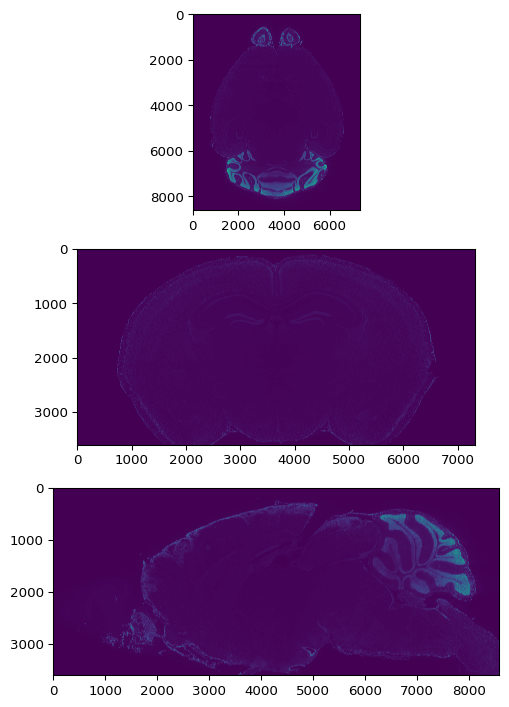

In [63]:
fig,ax = plt.subplots(3,1)
ax[0].imshow(vol_stack[vol_stack.shape[0] // 2, :, :])
ax[1].imshow(vol_stack[:, vol_stack.shape[1] // 2, :])
ax[2].imshow(vol_stack[:, :, vol_stack.shape[2] // 2])
fig.set_size_inches(6,9)

In [2]:
start_total = time.time()


# Laod 2D YOLO model
model_path = '/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo_saved_weights/modelsave_bright_on_dark.pt'
net = Net()
net.load_state_dict(torch.load(model_path))
B = net.B
stride = net.stride

# Load HDF5 3D input image
fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
vol = h5py.File(fname)
vol_stack = vol['stack']
curr_ax = 0 # [0,1,2]
next_idx = 3600

# outdir = f'/home/abenneck/Desktop/yolo3d_outputs/Ex_488_Em_525/ax{curr_ax}'
outdir = f'/nafs/shattuck/RodentToolsData/ZW-DT-1-P56-1/yolo3D_outputs_v01/ax{curr_ax}'

for idx in np.arange(vol_stack.shape[curr_ax]):

    if idx < next_idx:
        continue

    # Extract the slice 
    if curr_ax == 0:
        img = vol_stack[idx,:,:]
        out_fname = os.path.split(fname)[-1][:-3] + f'idx_{idx:05d}_:_:.npy'
    elif curr_ax == 1:
        img = vol_stack[:,idx,:]
        out_fname = os.path.split(fname)[-1][:-3] + f'idx_:_{idx:05d}_:.npy'
    elif curr_ax == 2:
        img = vol_stack[:,:,idx]
        out_fname = os.path.split(fname)[-1][:-3] + f'idx_:_:_{idx:05d}.npy'
    else:
        raise Exception(f'Invalid ax ({curr_ax}) supplied, only ({[k for k in range(2)]}) allowed')

    # Preprocess using gamma correction + upsampling
    start = time.time()
    img_up = preprocess(img)
    print(f'Finished preprocessing in {time.time()-start:.2f}s')
    
    # Extract tiles from the preprocessed input image
    padded_img, tiles = img_to_tiles(img_up, lower_threshold_bg = 0.04, verbose=True)
    
    # Apply model to tiles + apply bbox edge filtering
    print('Applying model to tiles . . .')
    out = apply_model_to_tiles(tiles, model_path, padded_img.shape[0], padded_img.shape[1], verbose=True)

    # Convert the raw model output into a more useful data structure
    print('Postprocessing . . .')
    pads = (np.array(padded_img.shape) - np.array(img_up.shape))/2
    out = torch.tensor(out.clone().detach(), dtype=torch.float32)
    out = postprocess(out, B, stride, pads, up_factor=2, verbose=True)

    # Save the processed output
    out_path = os.path.join(outdir, out_fname)
    if True:
        np.save(out_path, out)

    # # (11/19/25) Save some additional metadata in an npz file
    # out_fnamez = (img_path.split('/')[-1]).split('.')[0] + '_metadata.npz'
    # out_pathz = os.path.join(outdir, out_fnamez)
    # if False:
    #     np.savez(out_pathz,
    #             units = 'um',
    #             nrow_orig_img = img.shape[0],
    #             ncol_orig_img = img.shape[1],
    #             drow_orig_img = 1.866,
    #             dcol_orig_img = 1.866,
    #             dslice_orig_img = 2.0,
    #             nrow_upsampled_img = img_up.shape[0],
    #             ncol_upsampled_img = img_up.shape[1], 
    #             drow_upsampled_img = 3.732,
    #             dcol_upsampled_img = 3.732,
    #             pad_row_top = pads[0],
    #             pad_row_bot = pads[0],
    #             pad_col_left = pads[1],
    #             pad_col_right = pads[1],
    #             nrow = out.shape[0],
    #             ncol = out.shape[1],
    #             drow = 7.464,
    #             dcol = 7.464,
    #             note = "Bbox coords refer to the original image, with (0,0) corresponding to the top left pixel center"
    #             )    
        
    print(f'Saved the outputs for image {idx}/{vol_stack.shape[curr_ax]} in {time.time()-start_total:.2f}s\n')
    start_total = time.time()



Finished preprocessing in 4.81s
Finished extracting all tiles in 10.21s
Applying model to tiles . . .
Finished tiles 0:100/5082 in 0.63s
Finished tiles 100:300/5082 in 3.74s
Finished tiles 300:2800/5082 in 60.11s
Finished tiles 2800:3000/5082 in 19.20s
Finished applying model to entire image in 145.69s with 565/5082 (0.111) tiles marked as foreground
Postprocessing . . .


/tmp/ipykernel_399206/92284522.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  out = torch.tensor(out.clone().detach(), dtype=torch.float32)


Finished postprocessing in 0.48s
Saved the outputs for image 3599/3600 in 234.57s



## Plot Results

### Preprocess image

In [80]:
idx = 1500
fname = '/nafs/shattuck/RodentToolsData/Stacked/Ex_488_Em_525_stitched_chunk32.h5'
vol = h5py.File(fname)
vol_stack = vol['stack']
img = vol_stack[idx,:,:]

img_up = preprocess(img) # Normalize, gamma correction, upsample by factor of 2
padded_img, tiles = img_to_tiles(img_up, lower_threshold_bg = 0.04)
pads = (np.array(padded_img.shape) - np.array(img_up.shape))/2

nrow_t = int(np.max([tile['r_idx'] for tile in tiles])) + 1
ncol_t = int(np.max([tile['c_idx'] for tile in tiles])) + 1

ds = tileDataset(tiles)
dl = DataLoader(ds, batch_size = ncol_t, shuffle=False)

print(f'{nrow_t} x {ncol_t} tiles')

77 x 66 tiles


### Plot the image

Adding tiles . . .
Finished plotting tiles in 5.16s
Finished entire image in 6.00s


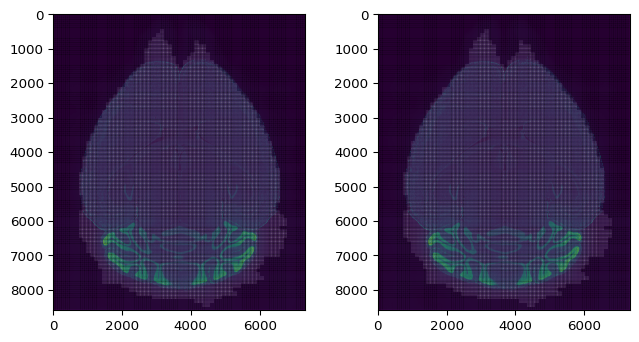

In [81]:
start_total = time.time()

plotBbox = False
addTiles = True
setBounds = False
tile_dim = 256

img_plot = preprocess(img, upsample=False)
tiles_plot = tiles_to_orig(tiles, pads)

fig, ax = plt.subplots(1,2)
for ax_i in ax:
    ax_i.imshow(img_plot)

if addTiles:
    print('Adding tiles . . .')
    start = time.time()
    for tile in tiles_plot:
        p = tile['p']
        bg = tile['bg']
        color = 'k' if bg else 'w'
        rec = Rectangle(p[::-1],tile_dim/2,tile_dim/2, facecolor=color, edgecolor='k', linewidth=3, alpha = 0.1)
        ax[0].add_patch(rec)
        rec = Rectangle(p[::-1],tile_dim/2,tile_dim/2, facecolor=color, edgecolor='k', linewidth=3, alpha = 0.1)
        ax[1].add_patch(rec)
    print(f'Finished plotting tiles in {time.time()-start:.2f}s')

if plotBbox:
    print('Plotting bboxes . . .')
    start = time.time()
    # scores = recon_batch[:,:,-4].ravel()
    # predicted_rectangles = bb_to_rec(recon_batch,fc='none',ec='lime',alpha=scores)
    # ax[0].add_collection(predicted_rectangles)
    # ax[0].set_title(f'recon_batch: {len(scores)} predictions')
    # print(f'Finished plotting bboxes0 in {time.time()-start:.2f}s, {len(scores)} boxes present')
    scores = recon_tile[:,:,-4].ravel()
    predicted_rectangles = bb_to_rec(recon_tile,fc='none',ec='lime',alpha=scores)
    ax[0].add_collection(predicted_rectangles)
    ax[0].set_title(f'recon: {len(scores)} predictions')
    print(f'Finished plotting bboxes0 in {time.time()-start:.2f}s, {len(scores)} boxes present')
    
    start = time.time()
    scores = recon_tile[:,:,-4].ravel()
    ec = ['red' if s==0 else 'lime' for s in scores]
    scores = [1 if s==0 else s for s in scores]
    # ec = 'lime'
    predicted_rectangles = bb_to_rec(recon_tile,fc='none',ec=ec,alpha=scores)
    ax[1].add_collection(predicted_rectangles)
    ax[1].set_title(f'recon_tile: {len(scores)} predictions')
    print(f'Finished plotting bboxes1 in {time.time()-start:.2f}s, {len(scores)} boxes present')

if setBounds:
    for ax_i in ax:
        # ax_i.set_xlim([3900,4000])
        # ax_i.set_ylim([5100,5000])
        # ax_i.set_xlim([3950,4050])
        # ax_i.set_ylim([5070,4970])
        ax_i.set_xlim([1500,6000])
        ax_i.set_ylim([8000,2500])

print(f'Finished entire image in {time.time()-start_total:.2f}s')

fig.set_size_inches(8,4)
fig.canvas.draw()
# plt.savefig(f'/home/abenneck/Desktop/yolo_model/tiles_{img_idx}.png')